# Vanilla PINN: Forward Problems

This notebook is the first full PINN training notebook in the core path.

We stay intentionally narrow: one PDE, one multilayer perceptron, one training loop, and one classical baseline. The goal is to make the mechanics of a vanilla PINN concrete before we branch into harder questions such as boundary-condition design, adaptive sampling, or inverse problems.


## Notebook Contract

- **Status:** core-executable
- **Research question:** Can a vanilla PINN with soft boundary penalties recover a simple forward PDE accurately enough to serve as our first end-to-end baseline?
- **Canonical problem:** 1D Poisson equation with Dirichlet boundary conditions
- **Main comparison:** trained PINN vs exact solution vs finite-difference baseline


## Why This Notebook Exists

Notebook `01` established three ideas: the PDE statement, a finite-difference baseline, and the derivative computations that autograd can provide.

This notebook now closes the loop:

- define a neural network surrogate $u_\theta(x)$,
- build the physics loss from the PDE residual,
- enforce boundary conditions with a soft penalty,
- optimize the model parameters,
- compare the learned solution against both the exact answer and a classical solver.

The problem is deliberately easy. If a vanilla PINN cannot solve this cleanly, it is too early to move to more advanced variants.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn

plt.style.use("seaborn-v0_8-whitegrid")
np.random.seed(7)
torch.manual_seed(7)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
repo_root = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / "pyproject.toml").exists())

print(f"Repo root: {repo_root}")
print(f"NumPy: {np.__version__}")
print(f"PyTorch: {torch.__version__}")
print(f"Device: {device}")


Repo root: /home/duncan-nguyen/research/physics-informed-learning
NumPy: 2.4.3
PyTorch: 2.10.0+cu128
Device: cpu


## Canonical PDE and PINN Objective

We solve the same boundary value problem used in notebook `01`:

$$
- u''(x) = f(x), \, x \in (0, 1), \qquad u(0) = u(1) = 0,
$$

with forcing term

$$
f(x) = \pi^2 \sin(\pi x).
$$

The exact solution is

$$
u^*(x) = \sin(\pi x).
$$

A vanilla PINN replaces the unknown function with a neural network $u_\theta(x)$ and minimizes

$$
\mathcal{L}(\theta) = \underbrace{\frac{1}{N_r}\sum_{i=1}^{N_r}\left|-u_\theta''(x_i^{(r)}) - f(x_i^{(r)})\right|^2}_{\text{physics loss}}
+ \lambda_{bc}\underbrace{\frac{1}{N_b}\sum_{j=1}^{N_b}\left|u_\theta(x_j^{(b)})\right|^2}_{\text{boundary loss}}.
$$

This is the simplest soft-constrained forward PINN we can write down.


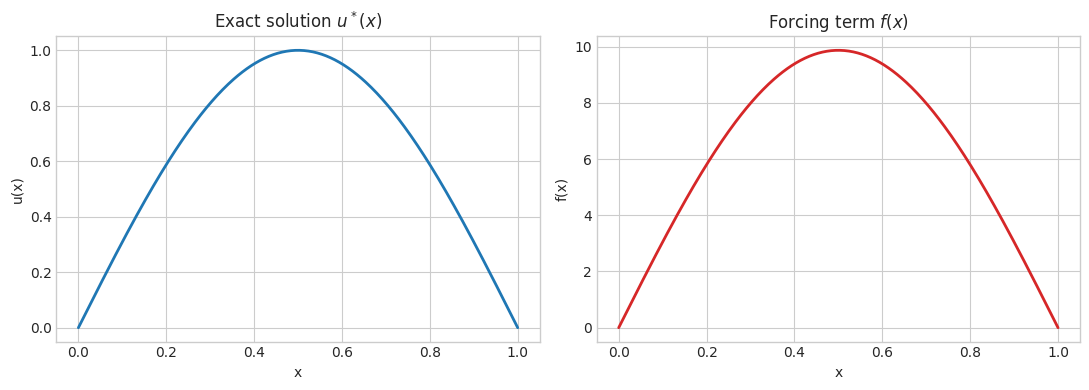

In [2]:
def exact_solution_np(x: np.ndarray) -> np.ndarray:
    return np.sin(np.pi * x)


def forcing_np(x: np.ndarray) -> np.ndarray:
    return (np.pi ** 2) * np.sin(np.pi * x)


def exact_solution_torch(x: torch.Tensor) -> torch.Tensor:
    return torch.sin(torch.pi * x)


def forcing_torch(x: torch.Tensor) -> torch.Tensor:
    return (torch.pi ** 2) * torch.sin(torch.pi * x)


x_plot = np.linspace(0.0, 1.0, 400)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(x_plot, exact_solution_np(x_plot), color="tab:blue", linewidth=2)
axes[0].set_title("Exact solution $u^*(x)$")
axes[0].set_xlabel("x")
axes[0].set_ylabel("u(x)")

axes[1].plot(x_plot, forcing_np(x_plot), color="tab:red", linewidth=2)
axes[1].set_title("Forcing term $f(x)$")
axes[1].set_xlabel("x")
axes[1].set_ylabel("f(x)")

plt.tight_layout()
plt.show()


## Finite-Difference Reference

A PINN is not competing on equal footing with a hand-built classical solver on this problem. That is exactly why the comparison is useful.

The finite-difference baseline gives us a reality check:

- how accurate a simple numerical method already is on this PDE,
- whether the PINN learns the right shape at all,
- whether a good-looking neural prediction is actually competitive with a cheap classical method.


Finite-difference max error: 1.285e-04
Finite-difference L2 error:  9.031e-05


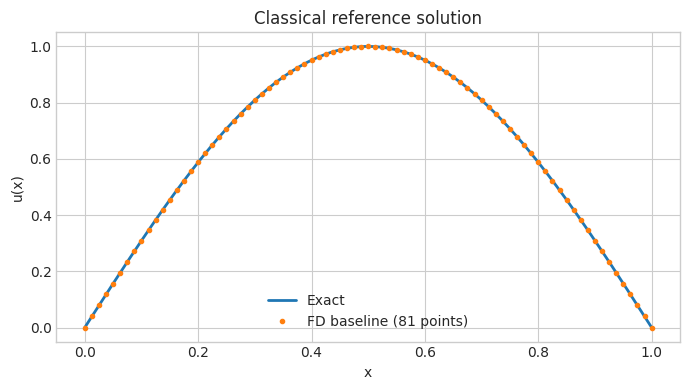

In [3]:
def solve_poisson_fd(num_grid_points: int):
    if num_grid_points < 3:
        raise ValueError("Need at least 3 grid points to have interior nodes.")

    x = np.linspace(0.0, 1.0, num_grid_points)
    h = x[1] - x[0]
    x_inner = x[1:-1]
    n_inner = len(x_inner)

    main_diag = 2.0 * np.ones(n_inner)
    off_diag = -1.0 * np.ones(n_inner - 1)
    A = (np.diag(main_diag) + np.diag(off_diag, k=1) + np.diag(off_diag, k=-1)) / (h ** 2)
    rhs = forcing_np(x_inner)

    u = np.zeros_like(x)
    u[1:-1] = np.linalg.solve(A, rhs)
    return x, u


x_fd, u_fd = solve_poisson_fd(num_grid_points=81)
u_exact_fd = exact_solution_np(x_fd)
fd_max_error = np.max(np.abs(u_fd - u_exact_fd))
fd_l2_error = np.sqrt(np.mean((u_fd - u_exact_fd) ** 2))

print(f"Finite-difference max error: {fd_max_error:.3e}")
print(f"Finite-difference L2 error:  {fd_l2_error:.3e}")

plt.figure(figsize=(7, 4))
plt.plot(x_plot, exact_solution_np(x_plot), label="Exact", linewidth=2)
plt.plot(x_fd, u_fd, "o", markersize=3, label="FD baseline (81 points)")
plt.xlabel("x")
plt.ylabel("u(x)")
plt.title("Classical reference solution")
plt.legend()
plt.tight_layout()
plt.show()


## PINN Ingredients

We now assemble the minimum pieces needed for training:

1. derivative helpers for $u_\theta'(x)$ and $u_\theta''(x)$,
2. a fixed set of interior collocation points,
3. two boundary points,
4. a small MLP with `tanh` activations,
5. a loss function that separates physics and boundary terms.

We keep the collocation set fixed so the training run stays deterministic and easy to reason about.


In [4]:
def gradient(y: torch.Tensor, x: torch.Tensor) -> torch.Tensor:
    return torch.autograd.grad(
        y,
        x,
        grad_outputs=torch.ones_like(y),
        create_graph=True,
        retain_graph=True,
    )[0]


def second_derivative(y: torch.Tensor, x: torch.Tensor) -> torch.Tensor:
    return gradient(gradient(y, x), x)


def make_interior_grid(num_points: int) -> torch.Tensor:
    x = torch.linspace(0.0, 1.0, num_points + 2, device=device).view(-1, 1)[1:-1]
    return x.clone().detach().requires_grad_(True)


def make_boundary_points() -> torch.Tensor:
    return torch.tensor([[0.0], [1.0]], device=device)


In [5]:
class VanillaPINN(nn.Module):
    def __init__(self, width: int = 32, depth: int = 2):
        super().__init__()
        layers: list[nn.Module] = [nn.Linear(1, width), nn.Tanh()]
        for _ in range(depth - 1):
            layers.extend([nn.Linear(width, width), nn.Tanh()])
        layers.append(nn.Linear(width, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


def pinn_loss(
    model: nn.Module,
    x_interior: torch.Tensor,
    x_boundary: torch.Tensor,
    bc_weight: float,
) -> dict[str, torch.Tensor]:
    u_interior = model(x_interior)
    residual = -second_derivative(u_interior, x_interior) - forcing_torch(x_interior)
    physics_loss = torch.mean(residual.square())
    boundary_loss = torch.mean(model(x_boundary).square())
    total_loss = physics_loss + bc_weight * boundary_loss
    return {
        "total": total_loss,
        "physics": physics_loss,
        "boundary": boundary_loss,
        "residual": residual,
    }


## Training a Vanilla PINN

This experiment uses a small, CPU-friendly configuration:

- `127` interior collocation points,
- `2` hidden layers of width `32`,
- Adam with learning rate `1e-3`,
- a boundary-condition weight of `50`,
- `2000` optimization steps.

That setup is intentionally plain. We want the first working notebook to expose the training mechanics rather than chase the best possible metric.


In [6]:
config = {
    "num_interior": 127,
    "width": 32,
    "depth": 2,
    "learning_rate": 1e-3,
    "bc_weight": 50.0,
    "steps": 2000,
}

x_interior = make_interior_grid(config["num_interior"])
x_boundary = make_boundary_points()

model = VanillaPINN(width=config["width"], depth=config["depth"]).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=config["learning_rate"])

history = {"step": [], "total": [], "physics": [], "boundary": []}

for step in range(1, config["steps"] + 1):
    optimizer.zero_grad()
    losses = pinn_loss(
        model=model,
        x_interior=x_interior,
        x_boundary=x_boundary,
        bc_weight=config["bc_weight"],
    )
    losses["total"].backward()
    optimizer.step()

    if step == 1 or step % 200 == 0:
        history["step"].append(step)
        history["total"].append(losses["total"].detach().item())
        history["physics"].append(losses["physics"].detach().item())
        history["boundary"].append(losses["boundary"].detach().item())
        print(
            f"step={step:4d} | total={history['total'][-1]:.3e} | "
            f"physics={history['physics'][-1]:.3e} | boundary={history['boundary'][-1]:.3e}"
        )


step=   1 | total=5.139e+01 | physics=5.116e+01 | boundary=4.779e-03
step= 200 | total=1.036e-02 | physics=1.034e-02 | boundary=3.734e-07
step= 400 | total=3.178e-03 | physics=3.177e-03 | boundary=2.586e-09
step= 600 | total=2.627e-03 | physics=2.627e-03 | boundary=4.203e-10
step= 800 | total=2.417e-03 | physics=2.417e-03 | boundary=3.183e-10
step=1000 | total=2.224e-03 | physics=2.224e-03 | boundary=1.876e-10
step=1200 | total=2.036e-03 | physics=2.036e-03 | boundary=1.370e-10
step=1400 | total=1.836e-03 | physics=1.836e-03 | boundary=1.011e-10
step=1600 | total=1.814e-03 | physics=1.609e-03 | boundary=4.101e-06
step=1800 | total=1.350e-03 | physics=1.347e-03 | boundary=4.296e-08
step=2000 | total=1.135e-03 | physics=1.135e-03 | boundary=6.137e-10


## Evaluation

We evaluate the trained network on a dense grid and compare three objects:

- the exact solution,
- the trained PINN prediction,
- the finite-difference reference.

We also inspect the training curves, the spatial error profile, and the PDE residual after training.


PINN max error:        1.867e-04
PINN L2 error:         9.078e-05
Mean |PDE residual|:   2.789e-02
Max  |PDE residual|:   1.799e-01
Boundary predictions:  [3.983453e-05 5.695969e-05]
FD max error:          1.285e-04
FD L2 error:           9.031e-05


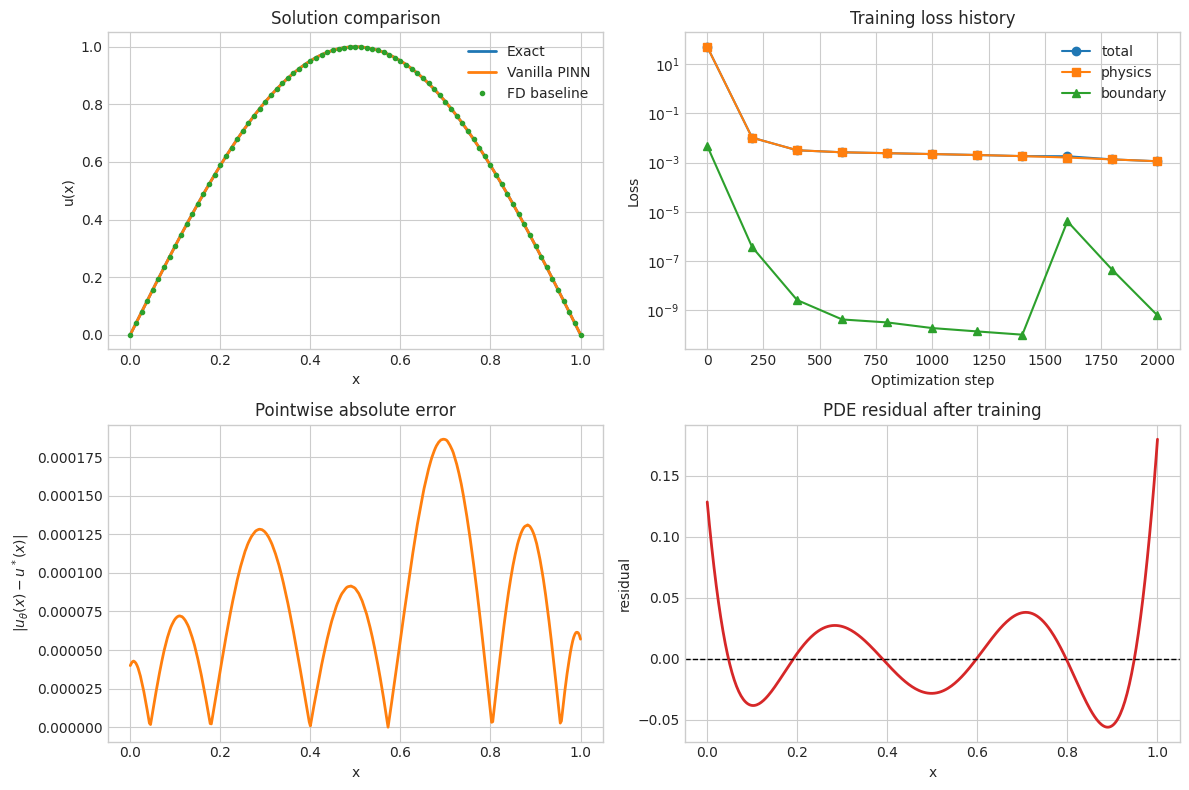

In [7]:
x_eval = torch.linspace(0.0, 1.0, 401, device=device).view(-1, 1)
x_eval = x_eval.clone().detach().requires_grad_(True)

u_pred = model(x_eval)
u_exact = exact_solution_torch(x_eval)
residual_eval = -second_derivative(u_pred, x_eval) - forcing_torch(x_eval)

pinn_max_error = torch.max(torch.abs(u_pred - u_exact)).detach().item()
pinn_l2_error = torch.sqrt(torch.mean((u_pred - u_exact).square())).detach().item()
mean_abs_residual = residual_eval.abs().mean().detach().item()
max_abs_residual = residual_eval.abs().max().detach().item()
boundary_values = model(x_boundary).detach().cpu().numpy().ravel()

print(f"PINN max error:        {pinn_max_error:.3e}")
print(f"PINN L2 error:         {pinn_l2_error:.3e}")
print(f"Mean |PDE residual|:   {mean_abs_residual:.3e}")
print(f"Max  |PDE residual|:   {max_abs_residual:.3e}")
print(f"Boundary predictions:  {boundary_values}")
print(f"FD max error:          {fd_max_error:.3e}")
print(f"FD L2 error:           {fd_l2_error:.3e}")

x_eval_np = x_eval.detach().cpu().numpy().ravel()
u_pred_np = u_pred.detach().cpu().numpy().ravel()
u_exact_np = u_exact.detach().cpu().numpy().ravel()
residual_np = residual_eval.detach().cpu().numpy().ravel()
abs_error_np = np.abs(u_pred_np - u_exact_np)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].plot(x_eval_np, u_exact_np, label="Exact", linewidth=2)
axes[0, 0].plot(x_eval_np, u_pred_np, label="Vanilla PINN", linewidth=2)
axes[0, 0].plot(x_fd, u_fd, "o", markersize=3, label="FD baseline")
axes[0, 0].set_title("Solution comparison")
axes[0, 0].set_xlabel("x")
axes[0, 0].set_ylabel("u(x)")
axes[0, 0].legend()

axes[0, 1].plot(history["step"], history["total"], "o-", label="total")
axes[0, 1].plot(history["step"], history["physics"], "s-", label="physics")
axes[0, 1].plot(history["step"], history["boundary"], "^-", label="boundary")
axes[0, 1].set_yscale("log")
axes[0, 1].set_title("Training loss history")
axes[0, 1].set_xlabel("Optimization step")
axes[0, 1].set_ylabel("Loss")
axes[0, 1].legend()

axes[1, 0].plot(x_eval_np, abs_error_np, color="tab:orange", linewidth=2)
axes[1, 0].set_title("Pointwise absolute error")
axes[1, 0].set_xlabel("x")
axes[1, 0].set_ylabel(r"$|u_\theta(x) - u^*(x)|$")

axes[1, 1].plot(x_eval_np, residual_np, color="tab:red", linewidth=2)
axes[1, 1].axhline(0.0, color="black", linewidth=1, linestyle="--")
axes[1, 1].set_title("PDE residual after training")
axes[1, 1].set_xlabel("x")
axes[1, 1].set_ylabel("residual")

plt.tight_layout()
plt.show()


## Interpretation

This notebook gives us a real first PINN baseline, but the conclusion should stay calibrated.

- The PINN can recover the smooth 1D Poisson solution with small error.
- The boundary penalty is enough to keep the endpoint predictions near zero.
- The physics loss drives the network toward the correct second-derivative structure.
- The finite-difference baseline is still extremely strong on this simple problem and remains the cheaper tool when the geometry and discretization are straightforward.

That last point matters. The value of PINNs is not that they automatically beat classical solvers on easy forward problems. Their value is that the formulation can stay flexible when we later change constraints, data availability, or problem structure.


## Key Takeaways

- A vanilla PINN is just a differentiable function approximator trained against PDE physics and boundary constraints.
- The training loop is mechanically simple: sample points, compute derivatives with autograd, build the loss, backpropagate, update parameters.
- Baselines matter. On this toy problem, a classical finite-difference solver is still a very competitive reference.
- The next notebook will stay on the same problem family and focus on a more subtle question: how should boundary and initial conditions be enforced?
